In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, VotingClassifier)

from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, roc_auc_score, f1_score)

In [2]:
df = pd.read_csv("penguins.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df["Species"].value_counts(normalize=True))

   CulmenLength  CulmenDepth  FlipperLength  BodyMass  Species
0          39.1         18.7          181.0    3750.0        0
1          39.5         17.4          186.0    3800.0        0
2          40.3         18.0          195.0    3250.0        0
3           NaN          NaN            NaN       NaN        0
4          36.7         19.3          193.0    3450.0        0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CulmenLength   342 non-null    float64
 1   CulmenDepth    342 non-null    float64
 2   FlipperLength  342 non-null    float64
 3   BodyMass       342 non-null    float64
 4   Species        344 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 13.6 KB
None
CulmenLength     2
CulmenDepth      2
FlipperLength    2
BodyMass         2
Species          0
dtype: int64
Species
0    0.441860
1    0.360465
2    0.197

In [3]:
# usuniecie brakujacych wartosci
df = df.dropna()

In [4]:
df.isnull().sum()

CulmenLength     0
CulmenDepth      0
FlipperLength    0
BodyMass         0
Species          0
dtype: int64

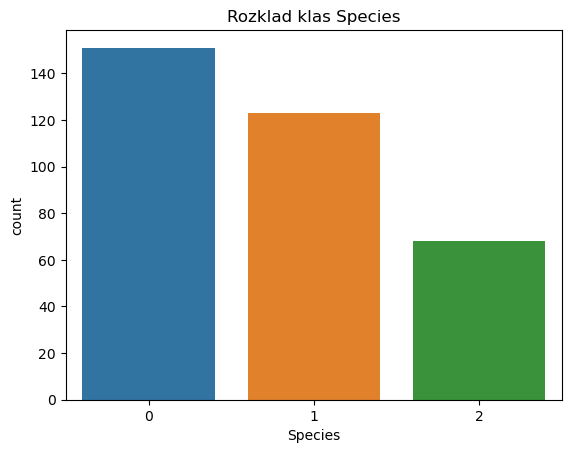

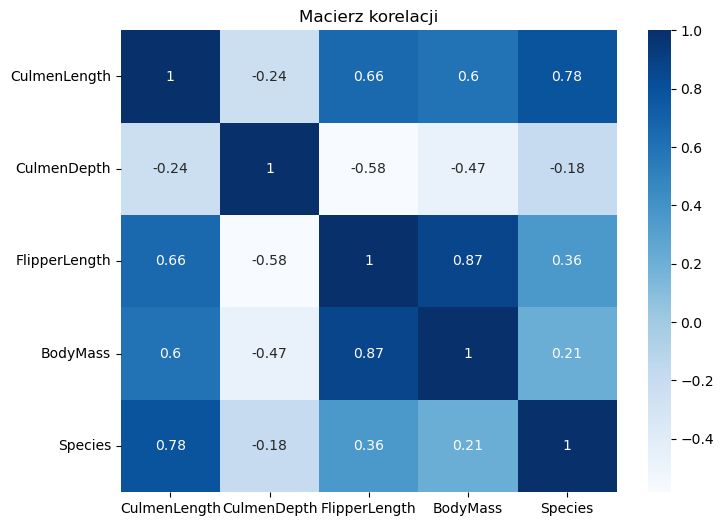

C:\Users\atrel\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


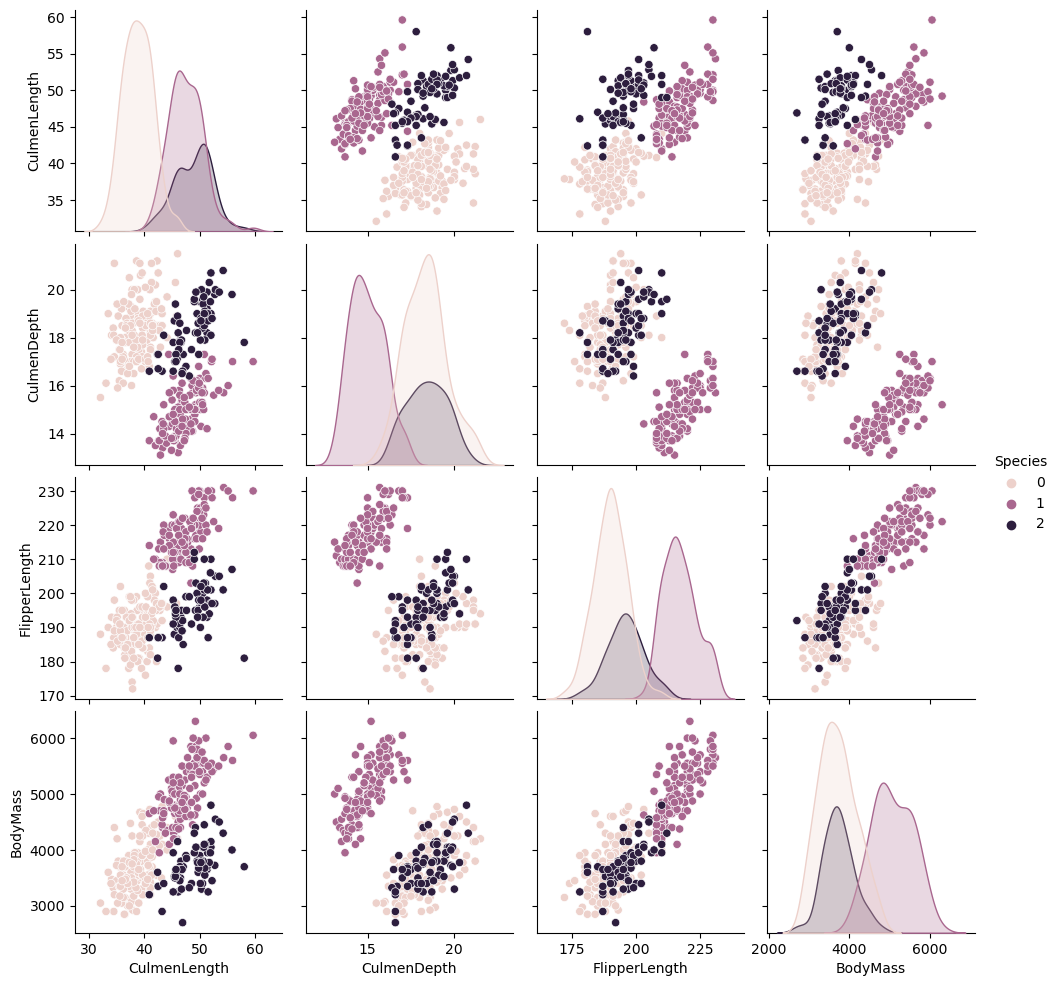

In [5]:
# Sprawdzenie danych
sns.countplot(data=df, x="Species")
plt.title("Rozklad klas Species")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Macierz korelacji")
plt.show()

sns.pairplot(df, hue="Species")
plt.show()

In [6]:
# Podzial na X i y

X = df.drop("Species", axis=1)
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# Skalowanie dancyh

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Funkcja calculate metrics - zadanie z poprzedniego modulu

metrics_dataframe = pd.DataFrame(columns=["Model", "F1_score", "AUC"])

models = []
models_names = []
predictions_proba_list = []

def calculate_metrics(model, name, X_checked, y_checked):
    global metrics_dataframe
    models.append(model)
    models_names.append(name)
    predictions = model.predict(X_checked)
    predictions_proba = model.predict_proba(X_checked)
    predictions_proba_list.append(predictions_proba)

    print(classification_report(y_checked, predictions))

    # Confusion matrix
    plt.figure()
    cm = confusion_matrix(y_checked, predictions)

    ax = sns.heatmap(
        cm,
        annot=True,
        cmap="Blues",
        fmt=".0f")
    ax.set_title("Confusion Matrix\n\n")
    ax.set_xlabel("\nPredicted Values")
    ax.set_ylabel("Actual Values")
    plt.show()

    # ROC Curve
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "k--")

    for model_selected, name_selected, pred_proba in zip(
        models,
        models_names,
        predictions_proba_list):
        y_true_bin = pd.get_dummies(y_checked).values

        fpr, tpr, thresholds = roc_curve(
            y_true_bin.ravel(),
            pred_proba.ravel())

        plt.plot(fpr, tpr, label=name_selected)
    plt.xlabel("False Positive Rates")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

    f1_metric = f1_score(
        y_checked,
        predictions,
        average="macro")

    auc_metric = roc_auc_score(
        y_checked,
        predictions_proba,
        multi_class="ovr")

    new_row = pd.DataFrame([{
        "Model": name,
        "F1_score": f1_metric,
        "AUC": auc_metric}])

    metrics_dataframe = pd.concat(
        [metrics_dataframe, new_row],
        ignore_index=True)

    return metrics_dataframe

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        14

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



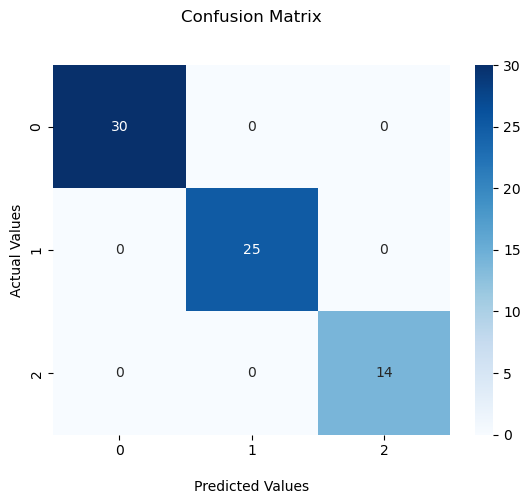

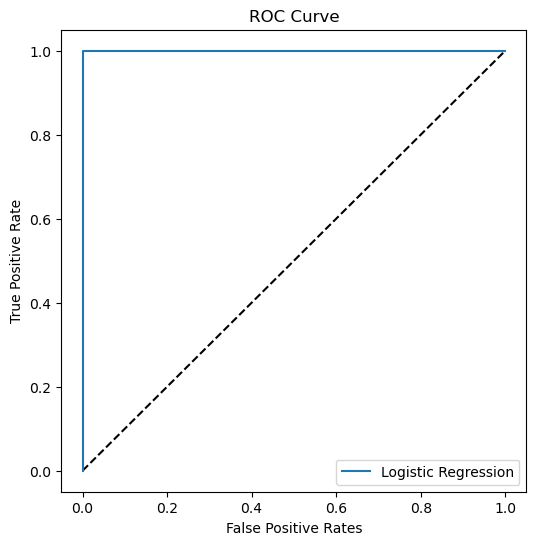

,Model,F1_score,AUC
0,Logistic Regression,1.0,1.0


In [9]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

calculate_metrics(
    lr_model,
    "Logistic Regression",
    X_test_scaled,
    y_test)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      1.00      1.00        25
           2       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



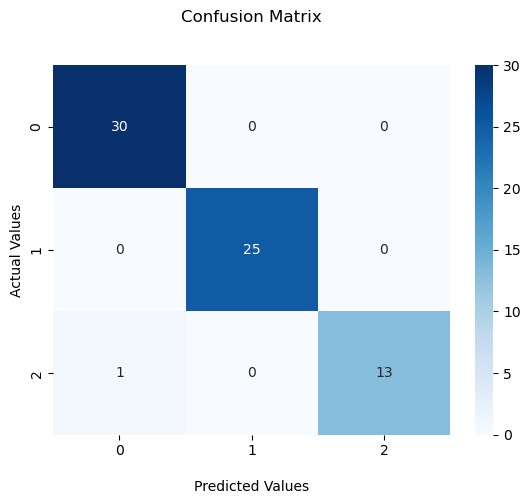

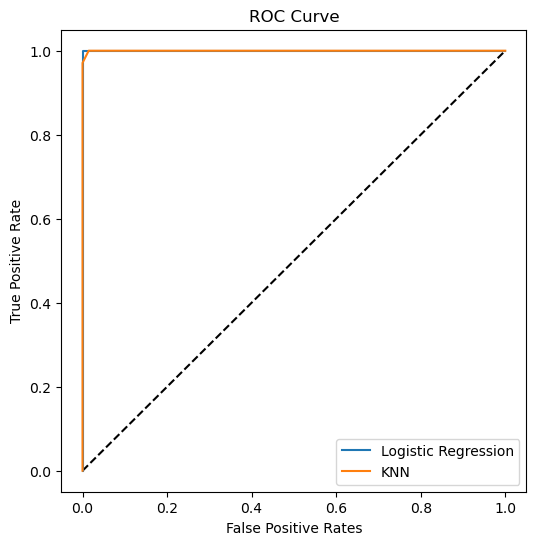

,Model,F1_score,AUC
0,Logistic Regression,1.00000,1.000000
1,KNN,0.98219,0.999641


In [10]:
# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

calculate_metrics(
    knn_model,
    "KNN",
    X_test_scaled,
    y_test)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      1.00      1.00        25
           2       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



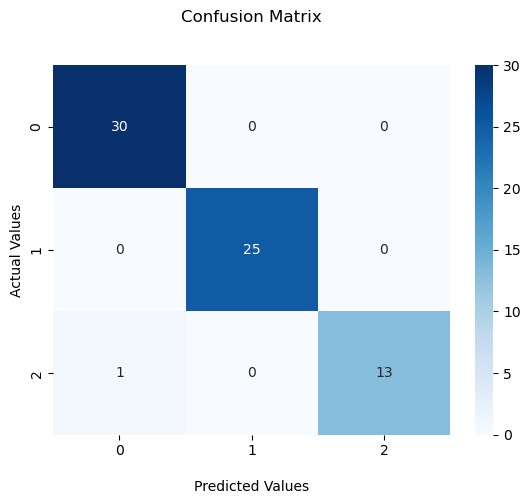

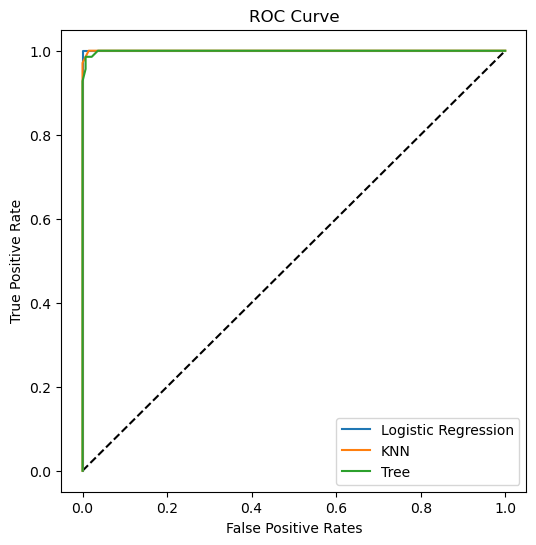

,Model,F1_score,AUC
0,Logistic Regression,1.00000,1.000000
1,KNN,0.98219,0.999641
2,Tree,0.98219,0.999282


In [11]:
# Decission tree

model_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
model_tree.fit(X_train, y_train)

calculate_metrics(model_tree, "Tree",
    X_test,
    y_test)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      1.00      1.00        25
           2       1.00      0.86      0.92        14

    accuracy                           0.97        69
   macro avg       0.98      0.95      0.96        69
weighted avg       0.97      0.97      0.97        69



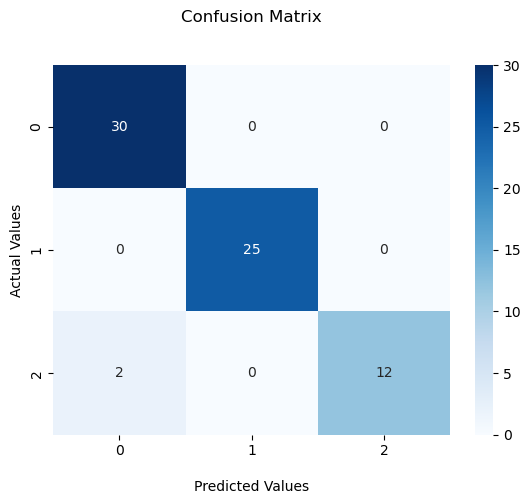

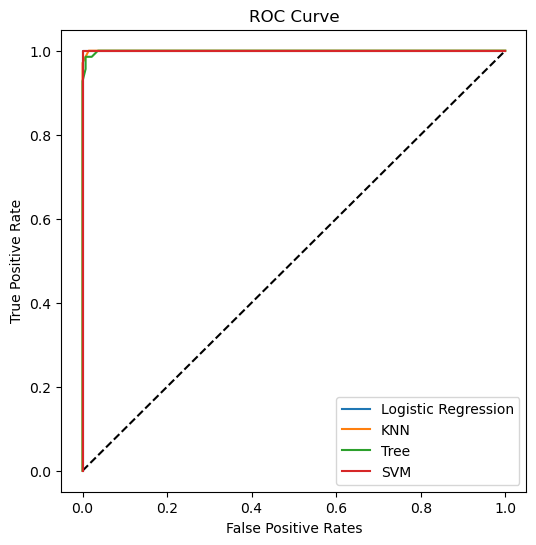

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
1,KNN,0.982190,0.999641
2,Tree,0.982190,0.999282
3,SVM,0.963606,1.000000


In [12]:
# SVM
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

calculate_metrics(
    svm_model,
    "SVM",
    X_test_scaled,
    y_test)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      1.00      1.00        25
           2       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



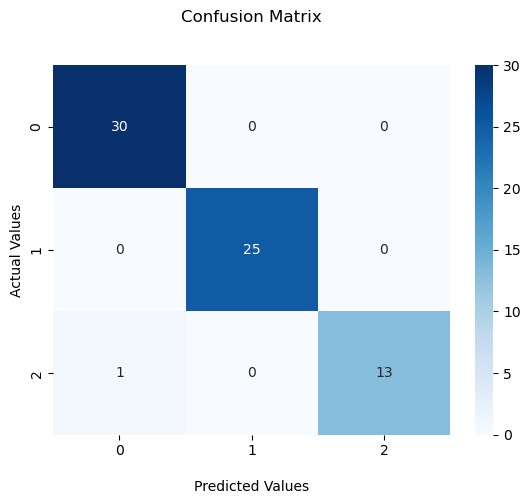

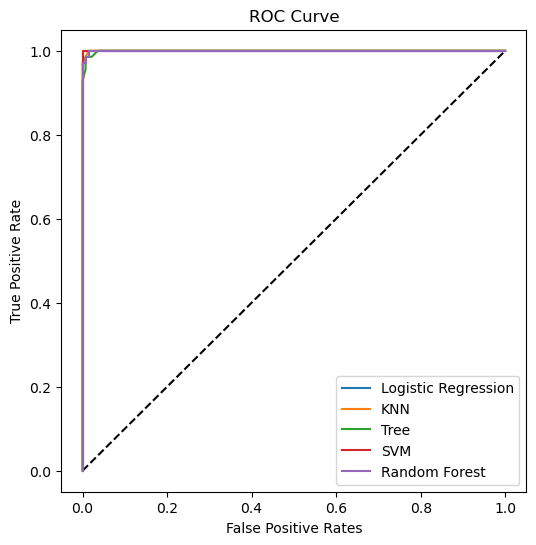

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
1,KNN,0.982190,0.999641
2,Tree,0.982190,0.999282
3,SVM,0.963606,1.000000
4,Random Forest,0.982190,0.999282


In [13]:
# Random forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

calculate_metrics(
    rf_model,
    "Random Forest",
    X_test,
    y_test)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        30
           1       1.00      1.00      1.00        25
           2       0.93      0.93      0.93        14

    accuracy                           0.97        69
   macro avg       0.97      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69



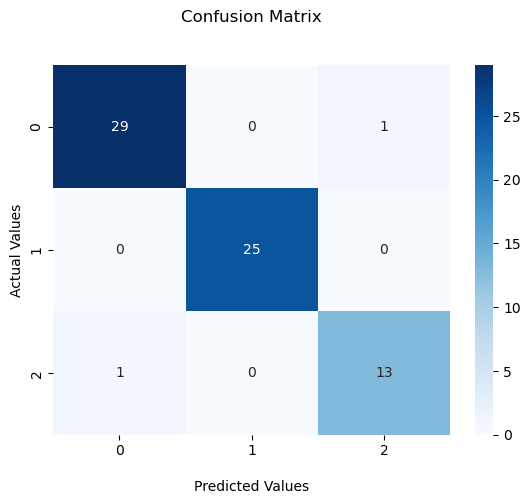

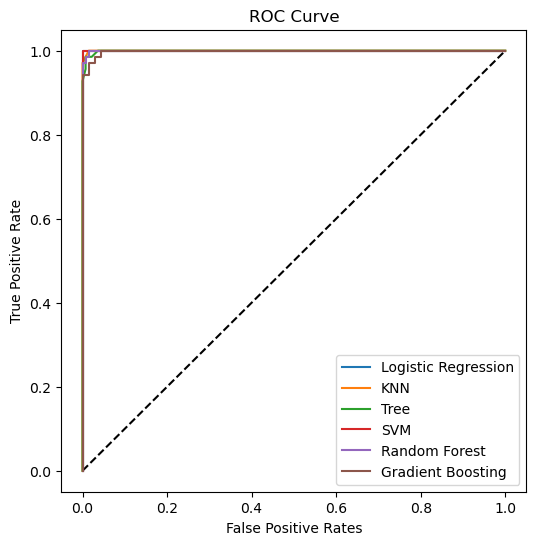

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
1,KNN,0.982190,0.999641
2,Tree,0.982190,0.999282
3,SVM,0.963606,1.000000
4,Random Forest,0.982190,0.999282
5,Gradient Boosting,0.965079,0.997847


In [14]:
# Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

calculate_metrics(
    gb_model,
    "Gradient Boosting",
    X_test,
    y_test)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      1.00      1.00        25
           2       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



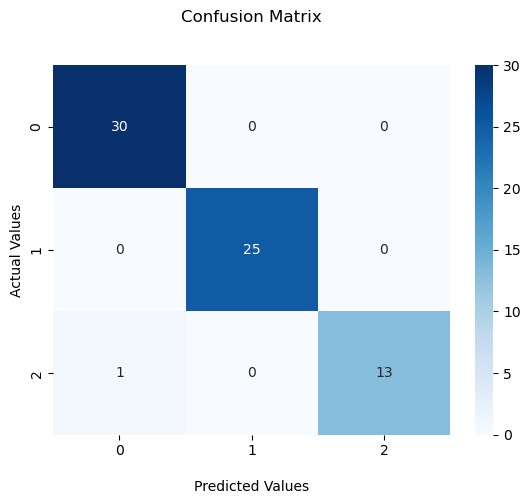

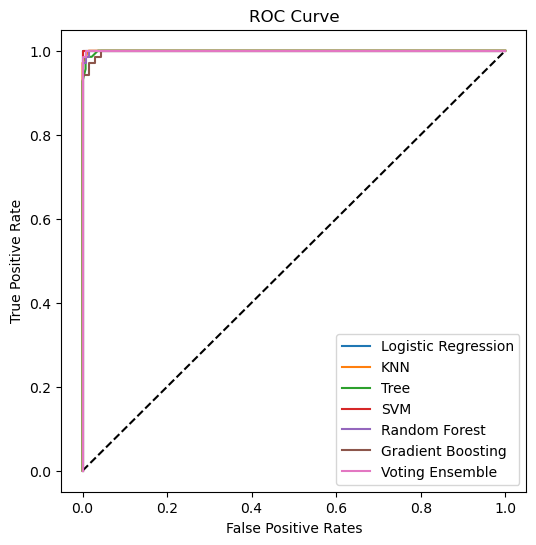

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
1,KNN,0.982190,0.999641
2,Tree,0.982190,0.999282
3,SVM,0.963606,1.000000
4,Random Forest,0.982190,0.999282
5,Gradient Boosting,0.965079,0.997847
6,Voting Ensemble,0.982190,1.000000


In [15]:
#Ensembling
voting_model = VotingClassifier(
    estimators=[
        ("lr", lr_model),
        ("knn", knn_model),
        ("tree", model_tree),
        ("svm", svm_model),
        ("rf", rf_model)],
    voting="soft")

voting_model.fit(X_train_scaled, y_train)

calculate_metrics(
    voting_model,
    "Voting Ensemble",
    X_test_scaled,
    y_test)

In [16]:
# Uzycie pipeline

# Pzygotownie danych
num_features = list(X.columns)
num_preparation = Pipeline(steps=[
    ("fill_missings", SimpleImputer(strategy="mean")),
    ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler_1", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("scaler_2", StandardScaler())])

data_preparation = ColumnTransformer(transformers=[
    ("numeric_preprocessing", num_preparation, num_features)])

model_pipeline = Pipeline(steps=[
    ("preprocessor", data_preparation),
    ("model", LogisticRegression(max_iter=10000))])

model_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric_preprocessing',
                                                  Pipeline(steps=[('fill_missings',
                                                                   SimpleImputer()),
                                                                  ('polynomial_features',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('scaler_1',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=0.95)),
                                                                  ('scaler_2',
                                                                   StandardScaler())]),
                                                  ['CulmenLength',
                                                   'CulmenDepth',
                                                   'FlipperLength',
                                                   'BodyMass'])])),
                ('model', LogisticRegression(max_iter=10000))])

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      1.00      1.00        25
           2       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



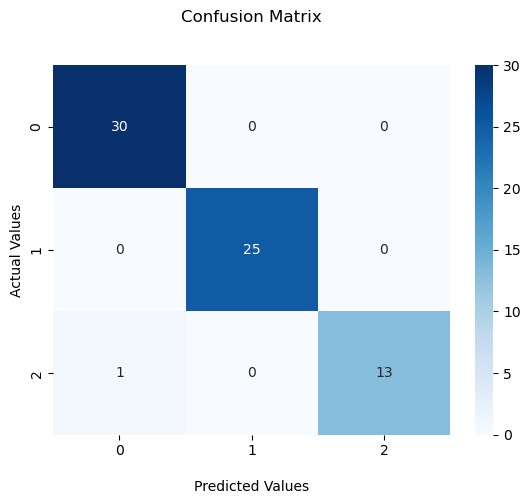

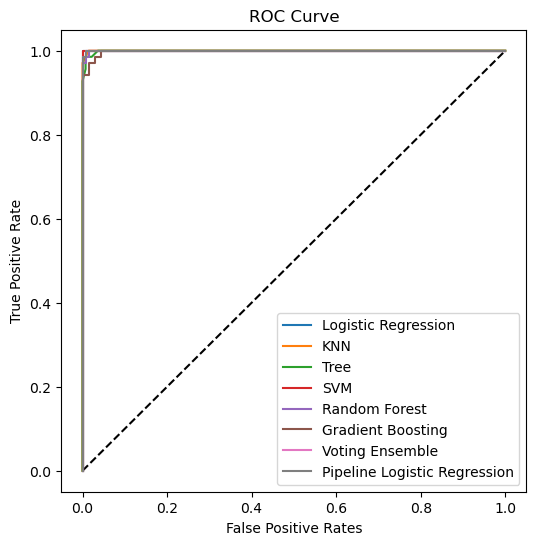

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
1,KNN,0.982190,0.999641
2,Tree,0.982190,0.999282
3,SVM,0.963606,1.000000
4,Random Forest,0.982190,0.999282
5,Gradient Boosting,0.965079,0.997847
6,Voting Ensemble,0.982190,1.000000
7,Pipeline Logistic Regression,0.982190,1.000000


In [17]:
# trenowanie pipeline
model_pipeline.fit(X_train, y_train)

calculate_metrics(
    model_pipeline,
    "Pipeline Logistic Regression",
    X_test,
    y_test)

In [18]:
# Tabela z porownaniem

metrics_dataframe.sort_values(
    by="F1_score",
    ascending=False)

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
1,KNN,0.982190,0.999641
2,Tree,0.982190,0.999282
4,Random Forest,0.982190,0.999282
6,Voting Ensemble,0.982190,1.000000
7,Pipeline Logistic Regression,0.982190,1.000000
5,Gradient Boosting,0.965079,0.997847
3,SVM,0.963606,1.000000
